| No | Visualization               | Why?                                     |
| -- | --------------------------- | ---------------------------------------- |
| 1  | Revenue Trend               | Business growth                          |
| 2  | Orders per Month            | Seasonality                              |
| 3  | Revenue by Category         | Best-performing categories               |
| 4  | Top 10 Sellers              | Seller performance                       |
| 5  | Revenue by State            | Regional performance                     |
| 6  | Payment Method Distribution | Customer payment preference              |
| 7  | Rating Distribution         | Customer satisfaction                    |
| 8  | Delivery Time Distribution  | Logistics performance                    |
| 9  | Top 10 Products             | Best-selling products                    |
| 10 | Correlation Heatmap         | Relationship between numerical variables |


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
customers = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\customers_clean.csv')
orders = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\orders_clean.csv')
products = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\products_clean.csv')
order_items = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\order_items_clean.csv')
payments = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\payments_clean.csv')
reviews = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\reviews_clean.csv')
sellers = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\sellers_clean.csv')
geolocation = pd.read_csv(r'D:\Ecommerce_Analytics_Project\Data\Cleaned\geolocation_clean.csv')

Revenue Trend Analysis

In [28]:
df = pd.merge(
    orders, payments,
    on = 'order_id',
    how= 'inner'
              )

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_month_name,order_day_name,order_quarter,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,Monday,4,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,Monday,4,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,Monday,4,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,Tuesday,3,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,Wednesday,3,1,credit_card,3,179.12


In [24]:
monthly_revenue = (
    df.groupby(['order_year', 'order_month'])['payment_value']
      .sum()
      .reset_index()
      .sort_values(by=['order_year', 'order_month'])
)
monthly_revenue.head(10)

,order_year,order_month,payment_value
0,2016,9,252.24
1,2016,10,59090.48
2,2016,12,19.62
3,2017,1,138488.04
4,2017,2,291908.01
5,2017,3,449863.60
6,2017,4,417788.03
7,2017,5,592918.82
8,2017,6,511276.38
9,2017,7,592382.92


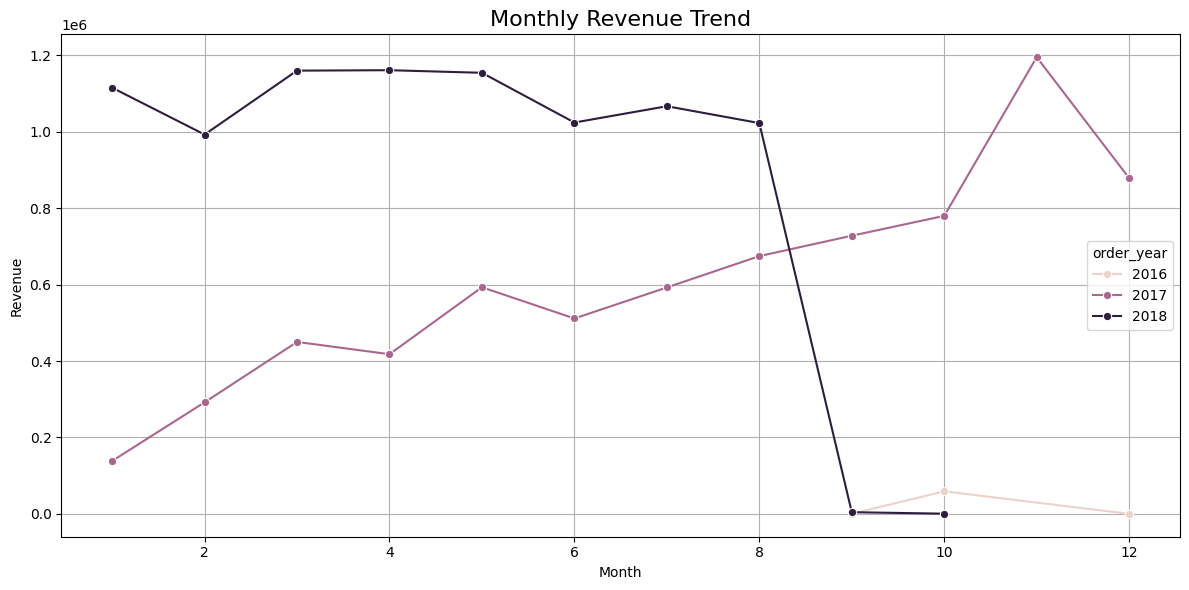

In [25]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x="order_month",
    y="payment_value",
    hue='order_year',   # hue tells Seaborn to split the data into separate colored lines based on order_year
    marker="o"
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)                 # Adds horizontal and vertical grid lines.
plt.tight_layout()             # Automatically adjusts spacing so labels and titles don't get cut off.

plt.show()

Orders Trend


In [26]:
monthly_orders = (
    orders.groupby(['order_year', 'order_month'])
          .size()
          .reset_index(name='total_orders')
          .sort_values(by=['order_year', 'order_month'])
)
monthly_orders.head(10)

,order_year,order_month,total_orders
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780
5,2017,3,2682
6,2017,4,2404
7,2017,5,3700
8,2017,6,3245
9,2017,7,4026


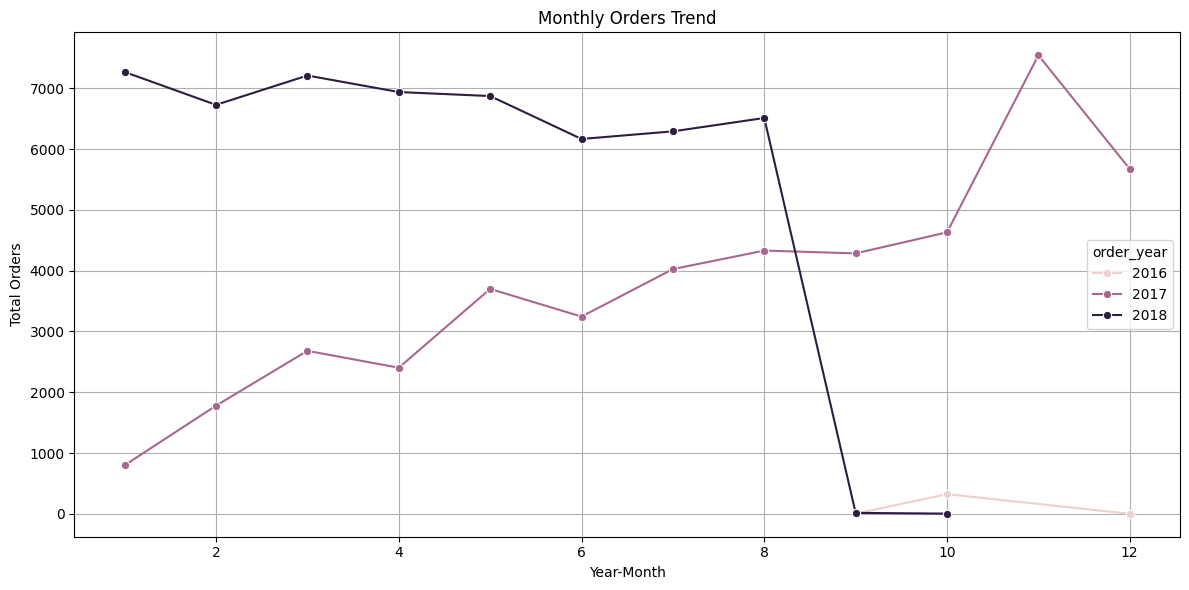

In [38]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_orders,
    x='order_month',
    y='total_orders',
    hue='order_year',
    marker='o'
)

plt.title('Monthly Orders Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Orders')
plt.grid(True)
plt.tight_layout()

plt.show()

Revenue by Product Category

In [32]:
df1 = pd.merge(
    order_items, products,
    on = 'product_id',
    how= 'inner'
              )

df1.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [52]:
product_revenue = (
    df1.groupby(['product_category_name'])['price']
       .sum()
       .reset_index()
       .sort_values(by='price', ascending=False)
)

top10 = product_revenue.head(10)

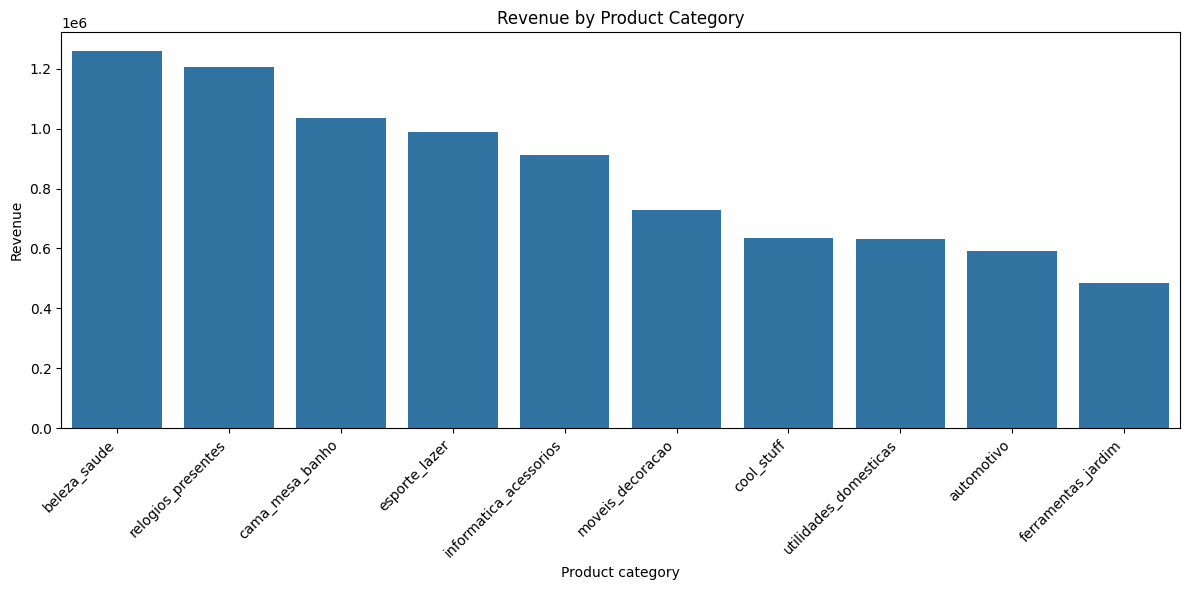

In [54]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10,
    x='product_category_name',
    y = 'price'
)

plt.title("Revenue by Product Category")
plt.xlabel("Product category")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

Top 10 Sellers by Revenue

In [59]:
df3 = pd.merge(
    order_items, sellers,
    on='seller_id',
    how='inner'
)
df3.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [61]:
seller_revenue = (
    df3.groupby(['seller_id'])['price']
    .sum()
    .reset_index()
    .sort_values(by='price', ascending=False)
)
seller10 = seller_revenue.head(10)

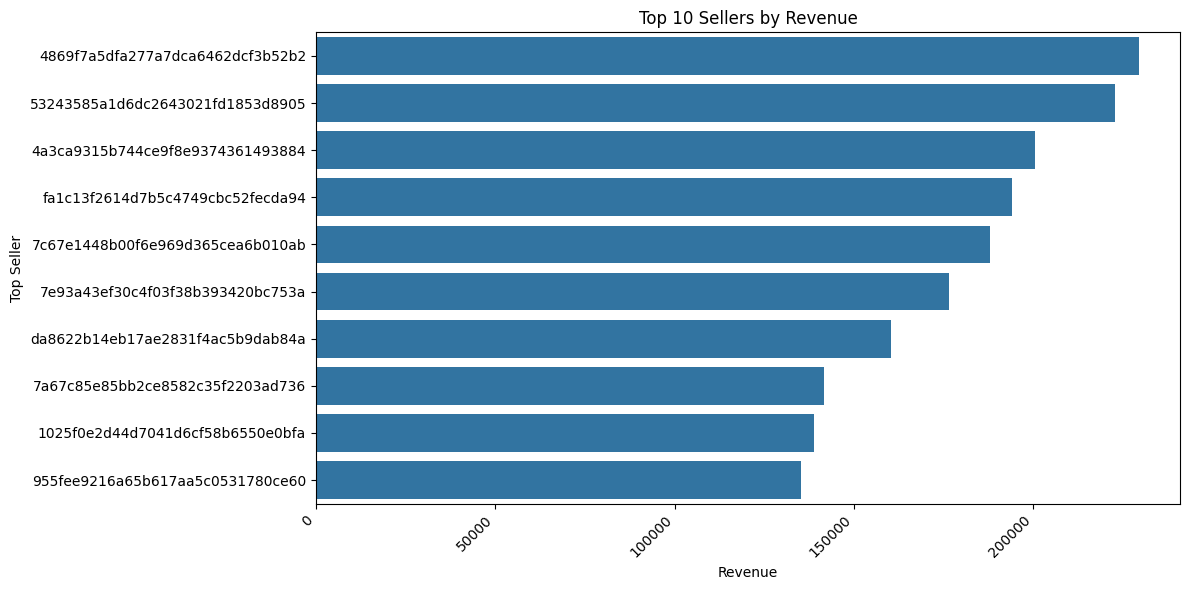

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=seller10,
    x='price',
    y='seller_id'
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Top Seller")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Revenue by State

In [80]:
dfa = pd.merge(
    customers, orders,
    on= 'customer_id', 
    how='inner'
)

dfb = pd.merge(
    dfa, payments,
    on= 'order_id',
    how='inner'
)

dfb.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,order_estimated_delivery_date,order_year,order_month,order_month_name,order_day_name,order_quarter,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,2017-06-05,2017,5,May,Tuesday,2,1,credit_card,2,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,2018-02-06,2018,1,January,Friday,1,1,credit_card,8,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,2018-06-13,2018,5,May,Saturday,2,1,credit_card,7,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,2018-04-10,2018,3,March,Tuesday,1,1,credit_card,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,2018-08-15,2018,7,July,Sunday,3,1,credit_card,8,252.25


In [87]:
state_revenue = (
    dfb.groupby(['customer_state'])['payment_value']
    .sum()
    .reset_index()
    .sort_values(by='payment_value')
)
state_revenue.head(10)

,customer_state,payment_value
21,RR,10064.62
3,AP,16262.80
0,AC,19680.62
2,AM,27966.93
20,RO,60866.20
26,TO,61485.33
24,SE,75246.25
1,AL,96962.06
19,RN,102718.13
16,PI,108523.97


AttributeError: module 'matplotlib.pyplot' has no attribute 'ylable'

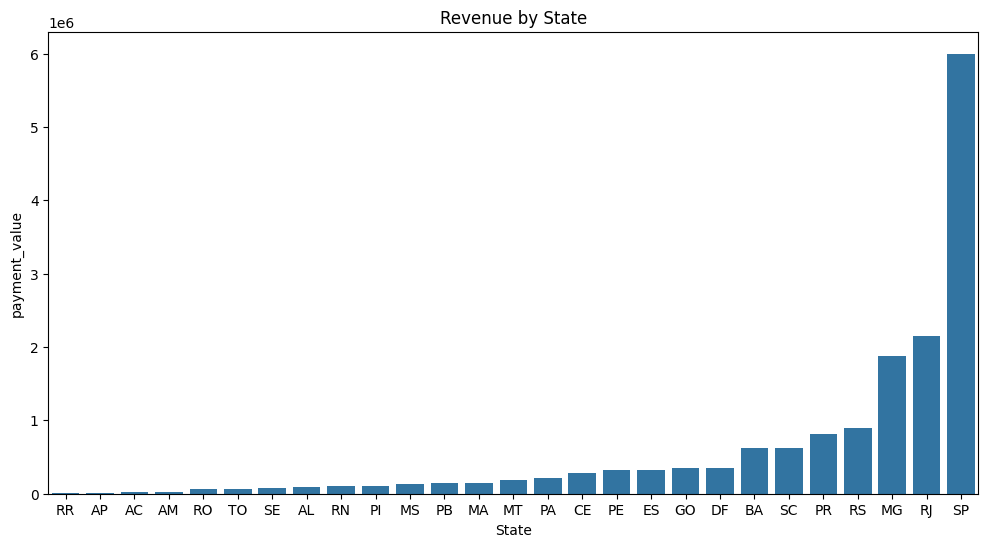

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_revenue,
    x = 'customer_state',
    y = 'payment_value'
)

plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.yticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
